In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df1 = pd.read_csv("user_competences_20260331.csv", sep=";")
df2 = pd.read_csv("user_competences_20260409.csv", sep=";")

In [ ]:
print(df1.shape)
print(df2.shape)

print(df1.columns.tolist())

(6809, 11)
(7100, 11)
['user_id', 'user_number', 'competence_id', 'competence_code', 'competence_name', 'probability', 'assessment_source', 'evidence_count', 'assessed_at', 'valid_from', 'valid_to']


In [ ]:
df1_last = (
    df1.sort_values("evidence_count")
    .groupby(["user_id", "competence_id"], as_index=False)
    .last()
)

df2_last = (
    df2.sort_values("evidence_count")
    .groupby(["user_id", "competence_id"], as_index=False)
    .last()
)

In [ ]:
merged = df1_last.merge(
    df2_last,
    on=["user_id", "competence_id"],
    suffixes=("_old", "_new"),
    how="inner"
)

merged["delta"] = merged["probability_new"] - merged["probability_old"]

In [ ]:
user_features = merged.groupby("user_id").agg(
    first_mean=("probability_old", "mean"),
    second_mean=("probability_new", "mean"),
    growth_mean=("delta", "mean"),
    growth_std=("delta", "std"),
    improved_count=("delta", lambda x: (x > 0).sum()),
    declined_count=("delta", lambda x: (x < 0).sum()),
    competence_count=("competence_id", "count")
).reset_index()

user_features["growth_std"] = user_features["growth_std"].fillna(0)

user_features.head()

,user_id,first_mean,second_mean,growth_mean,growth_std,improved_count,declined_count,competence_count
0,04faac8a-55ba-45e8-b22b-3defa5512390,0.288507,0.288507,0.000000,0.000000,0,0,32
1,0e24ff0e-c58a-4a6c-b054-e80df6607b99,0.036652,0.036652,0.000000,0.000000,0,0,30
2,17993c65-1f0e-4f0a-b458-a7c688b99ea0,0.259238,0.269128,0.009890,0.204015,17,23,64
3,2313e3e0-a834-4dfd-a62e-da6bf6bab116,0.008094,0.008094,0.000000,0.000000,0,0,5
4,363f7164-3a52-43aa-8b9b-b1677ed218ec,0.419408,0.457486,0.038078,0.087329,28,3,64


In [ ]:
X = user_features.drop(columns=["user_id"])

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_features["cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = user_features.groupby("cluster").mean(numeric_only=True)
cluster_summary

,first_mean,second_mean,growth_mean,growth_std,improved_count,declined_count,competence_count
cluster,,,,,,,
0,0.379138,0.379138,0.000000,0.000000,0.000000,0.000000,48.833333
1,0.048153,0.048444,0.000291,0.005305,0.444444,0.444444,17.555556
2,0.430806,0.458830,0.028024,0.133888,23.800000,6.400000,64.400000


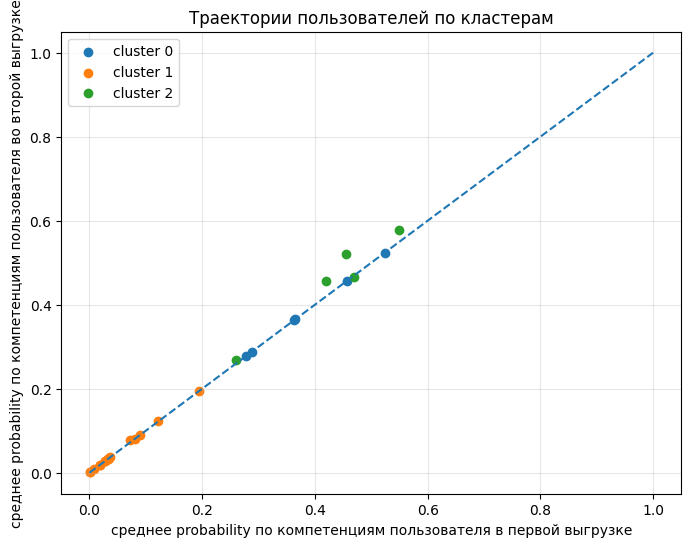

In [ ]:
plt.figure(figsize=(8,6))

for c in sorted(user_features["cluster"].unique()):
    temp = user_features[user_features["cluster"] == c]
    plt.scatter(temp["first_mean"], temp["second_mean"], label=f"cluster {c}")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("среднее probability по компетенциям пользователя в первой выгрузке")
plt.ylabel("среднее probability по компетенциям пользователя во второй выгрузке")
plt.title("Траектории пользователей по кластерам")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Пояснение к графику:

Каждая точка = один пользователь.

Пример(абстрактный):

- x = 0.30
- y = 0.45

В первой выгрузке средний уровень был 0.30, во второй стал 0.45, то есть пользователь вырос. Если точка на линии
> y = x

то уровень не изменился. Если точка выше линии - пользователь вырос. Если ниже - стал хуже.

In [ ]:
user_features["cluster"].value_counts() #смотрим размеры кластеров

,count
cluster,
1,18
0,6
2,5


In [ ]:
user_features.groupby("cluster")[["growth_mean","second_mean","improved_count"]].mean() #смотрим средние значения по кластерам

,growth_mean,second_mean,improved_count
cluster,,,
0,0.000000,0.379138,0.000000
1,0.000291,0.048444,0.444444
2,0.028024,0.458830,23.800000


In [ ]:
user_features[user_features["cluster"] == 2].sort_values("growth_mean", ascending=False)
#таблица лучших пользователей из cluster 2 - наиболее "развивающиеся" пользователи

,user_id,first_mean,second_mean,growth_mean,growth_std,improved_count,declined_count,competence_count,cluster
6,3f0b3f70-360a-4b6e-a96b-58306b6d98e8,0.455616,0.521906,0.066290,0.138714,28,0,59,2
4,363f7164-3a52-43aa-8b9b-b1677ed218ec,0.419408,0.457486,0.038078,0.087329,28,3,64,2
26,cae4ebf3-85b9-4e84-8229-c91d37325443,0.549580,0.578923,0.029343,0.076549,29,0,90,2
2,17993c65-1f0e-4f0a-b458-a7c688b99ea0,0.259238,0.269128,0.009890,0.204015,17,23,64,2
8,48f47d2f-9dbb-4a4d-a539-b85895db8ff3,0.470190,0.466708,-0.003482,0.162831,17,6,45,2


Пользователь:

> first 0.455 -> second 0.522

> improved_count = 28

> declined = 0

лучший пример успешной траектории

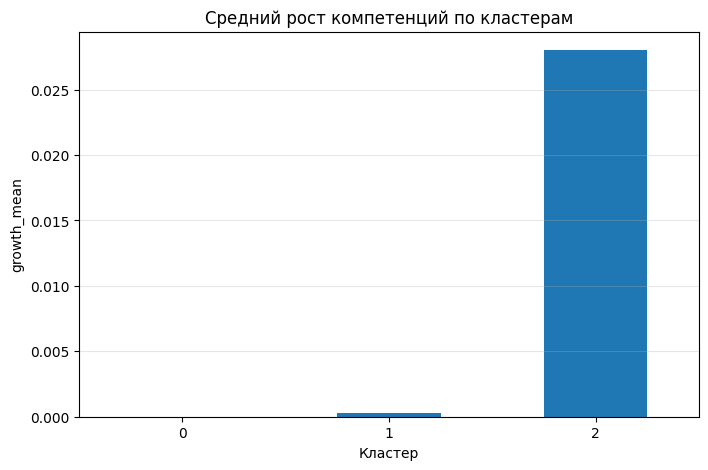

In [ ]:
user_features.groupby("cluster")["growth_mean"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Средний рост компетенций по кластерам")
plt.xlabel("Кластер")
plt.ylabel("growth_mean")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Идея задачи:**

> Посмотреть, можно ли выделить сценарии развития учеников во времени, понять, как меняются их компетенции между двумя выгрузками данных.

Я использовал две выгрузки user_competences за 31 марта 2026 и 9 апреля 2026. В этих данных для каждого пользователя есть *competence_id* (конкретная компетенция / навык) и *probability*, оценка уровня пользователя по этой компетенции.

Дальше я сопоставил одинаковые пары *user_id* + *competence_id* между первой и второй выгрузкой, чтобы для каждого пользователя посмотреть, как изменились значения по одним и тем же компетенциям со временем.

После этого для каждого пользователя я посчитал некоторые признаки, которые описывают его траекторию развития:

- first_mean: средний уровень компетенций в первой выгрузке
- second_mean: средний уровень компетенций во второй выгрузке
- growth_mean: среднее изменение уровня компетенций
- growth_std: насколько изменения были равномерными или нестабильными
- improved_count: сколько компетенций выросло
- declined_count: сколько снизилось
- competence_count: сколько компетенций удалось сравнить между двумя датами

Дальше я применил кластеризацию и разделил пользователей на 3 группы с похожими траекториями развития.

В результате получилось примерно следующее:

> Кластер 1: самая большая группа пользователей с низким уровнем компетенций и почти отсутствующим ростом. Это пользователи, у которых развитие практически не наблюдается. ☹

> Кластер 0: пользователи со средним уровнем компетенций, но без заметного роста.

> Кластер 2: небольшая группа пользователей с наиболее заметным ростом компетенций. У них намного (в сравнении) выше средний уровень и большое число улучшенных навыков.